In [ ]:
import os
os.listdir()

['.config', 'NSL_KDD_Test.csv', 'NSL_KDD_Train.csv', 'sample_data']

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
train = pd.read_csv("NSL_KDD_Train.csv")
test = pd.read_csv("NSL_KDD_Test.csv")

In [ ]:
print(train.head())

   0  tcp ftp_data   SF  491   0.1  0.2  0.3  0.4  0.5  ...   25  0.17  0.03  \
0  0  udp    other   SF  146     0    0    0    0    0  ...    1  0.00  0.60   
1  0  tcp  private   S0    0     0    0    0    0    0  ...   26  0.10  0.05   
2  0  tcp     http   SF  232  8153    0    0    0    0  ...  255  1.00  0.00   
3  0  tcp     http   SF  199   420    0    0    0    0  ...  255  1.00  0.00   
4  0  tcp  private  REJ    0     0    0    0    0    0  ...   19  0.07  0.07   

   0.17.1  0.25  0.26  0.27  0.05  0.28   normal  
0    0.88  0.00  0.00  0.00   0.0  0.00   normal  
1    0.00  0.00  1.00  1.00   0.0  0.00  neptune  
2    0.03  0.04  0.03  0.01   0.0  0.01   normal  
3    0.00  0.00  0.00  0.00   0.0  0.00   normal  
4    0.00  0.00  0.00  0.00   1.0  1.00  neptune  

[5 rows x 42 columns]


In [ ]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (125972, 42)
Test Shape: (22543, 42)


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 42 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   0         125972 non-null  int64  
 1   tcp       125972 non-null  object 
 2   ftp_data  125972 non-null  object 
 3   SF        125972 non-null  object 
 4   491       125972 non-null  int64  
 5   0.1       125972 non-null  int64  
 6   0.2       125972 non-null  int64  
 7   0.3       125972 non-null  int64  
 8   0.4       125972 non-null  int64  
 9   0.5       125972 non-null  int64  
 10  0.6       125972 non-null  int64  
 11  0.7       125972 non-null  int64  
 12  0.8       125972 non-null  int64  
 13  0.9       125972 non-null  int64  
 14  0.10      125972 non-null  int64  
 15  0.11      125972 non-null  int64  
 16  0.12      125972 non-null  int64  
 17  0.13      125972 non-null  int64  
 18  0.14      125972 non-null  int64  
 19  0.15      125972 non-null  int64  
 20  0.16

In [ ]:
train.isnull().sum()

,0
0,0
tcp,0
ftp_data,0
SF,0
491,0
0.1,0
0.2,0
0.3,0
0.4,0
0.5,0


In [ ]:
print(train.columns)

Index(['0', 'tcp', 'ftp_data', 'SF', '491', '0.1', '0.2', '0.3', '0.4', '0.5',
       '0.6', '0.7', '0.8', '0.9', '0.10', '0.11', '0.12', '0.13', '0.14',
       '0.15', '0.16', '0.18', '2', '2.1', '0.19', '0.20', '0.21', '0.22', '1',
       '0.23', '0.24', '150', '25', '0.17', '0.03', '0.17.1', '0.25', '0.26',
       '0.27', '0.05', '0.28', 'normal'],
      dtype='object')


In [ ]:
import pandas as pd

columns = [
'duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
'wrong_fragment','urgent','hot','num_failed_logins','logged_in',
'num_compromised','root_shell','su_attempted','num_root',
'num_file_creations','num_shells','num_access_files','num_outbound_cmds',
'is_host_login','is_guest_login','count','srv_count','serror_rate',
'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate',
'diff_srv_rate','srv_diff_host_rate','dst_host_count','dst_host_srv_count',
'dst_host_same_srv_rate','dst_host_diff_srv_rate',
'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
'dst_host_srv_rerror_rate','class','difficulty'
]

train = pd.read_csv("NSL_KDD_Train.csv", names=columns)
test = pd.read_csv("NSL_KDD_Test.csv", names=columns)

train = train.drop("difficulty", axis=1)
test = test.drop("difficulty", axis=1)

In [ ]:
train['class'] = train['class'].apply(lambda x: 0 if x == 'normal' else 1)
test['class'] = test['class'].apply(lambda x: 0 if x == 'normal' else 1)

In [ ]:
X_train = train.drop("class", axis=1)
y_train = train["class"]

X_test = test.drop("class", axis=1)
y_test = test["class"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
print(train['class'].value_counts())

class
0    67343
1    58630
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=25, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.7717796309439319


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

models = {
    "Random Forest": RandomForestClassifier(n_estimators=200),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    print(name, "Accuracy:", acc)

Random Forest Accuracy: 0.7753726046841731
Decision Tree Accuracy: 0.7835787792760823
SVM Accuracy: 0.7819375443577005
KNN Accuracy: 0.7675656493967353


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.66      0.97      0.79      9711
           1       0.97      0.62      0.76     12833

    accuracy                           0.77     22544
   macro avg       0.81      0.80      0.77     22544
weighted avg       0.83      0.77      0.77     22544



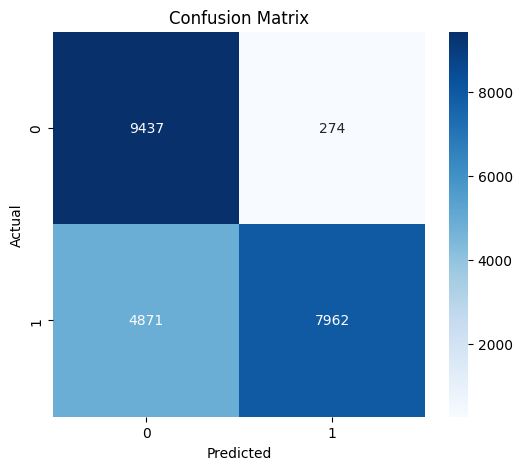

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()